### STEP 1: SETUP & RETURN CALCULATIONS

Database Connected successfully


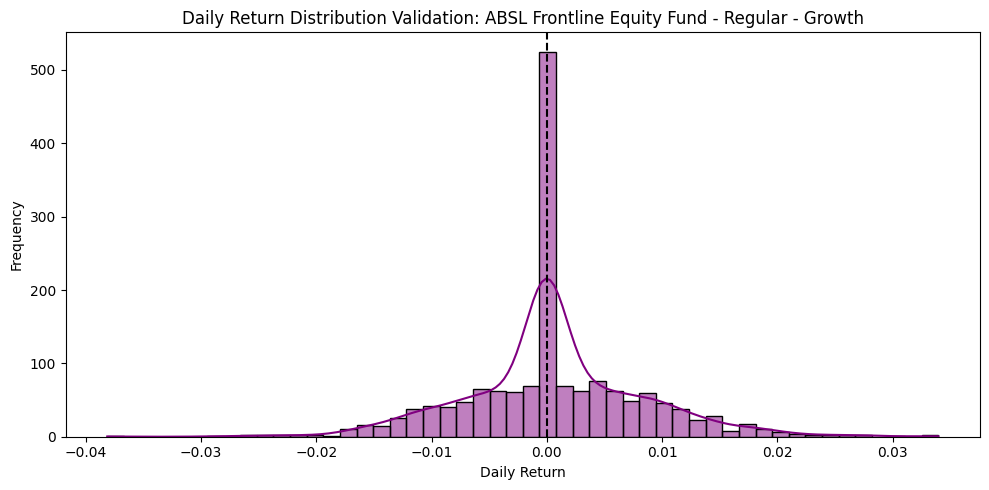


 CAGR Comparison Table (Top 10 Funds):


,Scheme Name,1Y CAGR (%),3Y CAGR (%),5Y CAGR (%)
0,ABSL Frontline Equity Fund - Regular - Growth,47.96,28.96,23.54
1,ABSL Liquid Fund - Regular - Growth,7.24,6.31,6.51
2,ABSL Small Cap Fund - Regular - Growth,-24.00,-4.15,7.94
3,Axis Bluechip Fund - Direct - Growth,19.78,20.81,7.90
4,Axis Bluechip Fund - Regular - Growth,1.61,0.53,6.37
5,Axis Midcap Fund - Regular - Growth,22.28,35.10,28.21
6,Axis Small Cap Fund - Regular - Growth,-42.82,-11.70,1.52
7,DSP Midcap Fund - Regular - Growth,21.50,26.86,29.58
8,DSP Small Cap Fund - Regular - Growth,65.20,26.99,32.29
9,DSP Top 100 Equity Fund - Regular - Growth,18.12,18.04,13.39


In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 1. Connect to Database and Load Data
conn = sqlite3.connect("../data/db/bluestock_mf.db")
df_nav = pd.read_sql_query("SELECT * FROM fact_nav", conn)
df_fund = pd.read_sql_query("SELECT * FROM dim_fund", conn)

print("Database Connected successfully")

# Format dates and merge to get scheme names
df_nav['nav_date'] =pd.to_datetime(df_nav['nav_date'])
df_nav_merged = pd.merge(df_nav, df_fund[['amfi_code', 'scheme_name']], on='amfi_code')

# Create a Pivot Table (Rows = Dates, Columns = Schemes, Values = NAV)
nav_pivot = df_nav_merged.pivot_table(index='nav_date', columns='scheme_name', values= 'nav')


# 2. Compute Daily Returns
# pct_change() automatically calculates (NAV_today / NAV_yesterday) - 1
daily_returns = nav_pivot.pct_change().dropna(how='all')

# Validate Distribution: Plotting a histogram of daily returns for the first fund
plt.figure(figsize=(10, 5))
first_fund = daily_returns.columns[0]
sns.histplot(daily_returns[first_fund].dropna(), bins=50, kde=True, color='purple')
plt.title(f'Daily Return Distribution Validation: {first_fund}')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()



# 3. Compute CAGR (1Yr, 3Yr, 5Yr)
cagr_results= []
for fund in nav_pivot.columns:
    fund_nav = nav_pivot[fund].dropna()
    if fund_nav.empty:
        continue
    nav_end = fund_nav.iloc[-1]
    end_date =fund_nav.index[-1]
    
    # Helper function to calculate CAGR for 'n' years
    def get_cagr(years):
        start_date = end_date - pd.DateOffset(years=years)
        available_data = fund_nav[fund_nav.index >= start_date]
        
        # If we don't have enough data (e.g., trying to find 5yr data when we only have 4yrs)
        if available_data.empty or (end_date - available_data.index[0]).days < (years * 365 * 0.8):
            return np.nan
        
        nav_start = available_data.iloc[0]
        actual_years = (end_date - available_data.index[0]).days / 365.25
        return ((nav_end / nav_start) ** (1 / actual_years)) - 1
    
    # Calculate 1Y, 3Y, and 5Y CAGR
    cagr_1y = get_cagr(1)
    cagr_3y = get_cagr(3)
    cagr_5y = get_cagr(5)
    
    cagr_results.append({
        'Scheme Name' : fund,
        '1Y CAGR (%)' : round(cagr_1y * 100, 2) if pd.notna(cagr_1y) else np.nan,
        '3Y CAGR (%)' : round(cagr_3y * 100, 2) if pd.notna(cagr_3y) else np.nan,
        '5Y CAGR (%)' : round(cagr_5y * 100, 2) if pd.notna(cagr_5y) else np.nan,
    })
    
# Convert to DataFrame for a clean comparison table
df_cagr = pd.DataFrame(cagr_results)

print("\n CAGR Comparison Table (Top 10 Funds):")
display(df_cagr.head(10))

### STEP 2: RISK METRICS CALCULATION

In [10]:
import numpy as np

# Risk-Free Rate (RBI Repo Rate Proxy = 6.5%)
risk_free_rate = 0.065
trading_days = 252 # Average trading days in a year



# 1. Annualized Return & Volatility
# Convert daily mean return to annualized return
annual_return = daily_returns.mean() * trading_days

# Convert daily standard deviation to annualized volatility
annual_volatility = daily_returns.std() * np.sqrt(trading_days)



# 2. Compute Sharpe Ratio
# Formula: (Return - Risk Free Rate) / Volatility
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility



# 3. Compute Sortino Ratio
# Filter only negative returns for downside deviation
downside_returns = daily_returns[daily_returns < 0]
downside_volatility = downside_returns.std() * np.sqrt(trading_days)

# Formula: (Return - Risk Free Rate) / Downside Volatility
sortino_ratio = (annual_return - risk_free_rate)/ downside_volatility



# 4. Compute Maximum Drawdown
# Calculate the running maximum of the NAV
running_max = nav_pivot.cummax()

# Calculate the drawdown: (Current NAV / Running Max) - 1
drawdown = (nav_pivot / running_max) - 1

# Get the maximum drop (minimum value since it's negative)
max_drawdown = drawdown.min()



# 5. Compile Results & Rank Funds
risk_metrics = pd.DataFrame({
    'Annualized Return': round(annual_return * 100, 2),
    'Volatility (%)' : round(annual_volatility * 100, 2),
    'Sharpe Ratio' : round(sharpe_ratio,2),
    'Sortino Ratio' : round(sortino_ratio, 2),
    'Max Drawdown (%)' :  round(max_drawdown * 100, 2)
})

# Rank all 40 funds based on Sharpe Ratio (1 is the best)
risk_metrics['Sharpe Rank'] = risk_metrics['Sharpe Ratio'].rank(ascending=False).astype(int)

# Sort by rank to see the top performers
risk_metrics_sorted = risk_metrics.sort_values('Sharpe Rank')

print("/n Fund Risk Metrics & Sharpe Ranking (Top 10 Funds):")
display(risk_metrics_sorted.head(10))


/n Fund Risk Metrics & Sharpe Ranking (Top 10 Funds):


,Annualized Return,Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Sharpe Rank
scheme_name,,,,,,
Mirae Asset Large Cap Fund - Regular - Growth,19.35,12.03,1.07,1.49,-11.27,1
Kotak Flexicap Fund - Regular - Growth,19.49,13.45,0.97,1.48,-12.97,2
Mirae Asset Tax Saver Fund - Regular - Growth,20.25,14.96,0.92,1.35,-16.40,3
ICICI Pru Midcap Fund - Regular - Growth,20.92,16.33,0.88,1.29,-18.19,4
SBI Bluechip Fund - Regular Plan - Growth,16.52,11.64,0.86,1.29,-15.01,5
DSP Midcap Fund - Regular - Growth,19.01,15.02,0.83,1.17,-17.25,6
HDFC Mid-Cap Opportunities Fund - Regular - Growth,19.46,16.03,0.81,1.14,-16.22,7
Nippon India Large Cap Fund - Regular - Growth,15.59,11.98,0.76,1.10,-17.41,8
Axis Midcap Fund - Regular - Growth,18.50,16.42,0.73,1.06,-20.96,9


### STEP 3: ALPHA & BETA CALCULATION

In [12]:
from scipy import stats
import pandas as pd
import os

# Since we might not have a separate Nifty 100 CSV,
# we use the equal-weighted average of all 40 funds as our "Market Proxy" (Benchmark).
market_returns = daily_returns.mean(axis=1)

alpha_beta_results = []

# Calculate Alpha and Beta for each fund
for fund in daily_returns.columns:
    # Align fund returns and market returns (drop missing days)
    valid_data = pd.concat([daily_returns[fund], market_returns], axis=1).dropna()
    fund_ret = valid_data.iloc[:, 0]
    mkt_ret = valid_data.iloc[:, 1]
     
    if len(fund_ret) < 10:
        continue
    
    # Perform OLS Regression using scipy.stats
    slope, intercept, r_value, p_value, std_err = stats.linregress(mkt_ret, fund_ret)
    
    # Beta is the slope of the regression line
    beta = slope
    
    # Alpha is the intercept, annualized (multiplied by 252 trading days)
    alpha_annualized = intercept * 252
    
    alpha_beta_results.append({
        'Scheme Name': fund,
        'Alpha (%)' : round(alpha_annualized * 100, 2),
        'Beta' : round(beta, 2),
        'R-Squared' : round(r_value**2, 2)
    })
    
# Convert to DataFrame
df_alpha_beta = pd.DataFrame(alpha_beta_results)

# Sort by Alpha (Highest first) to see which funds beat the market
df_alpha_beta_sorted = df_alpha_beta.sort_values(by='Alpha (%)', ascending=False).reset_index(drop=True)

print("\n Fund Alpha & Beta Analysis (Top 10 Funds by Alpha): ")
display(df_alpha_beta_sorted.head(10))

# Export to CSV as requested in deliverables
os.makedirs('../reports', exist_ok=True)
df_alpha_beta_sorted.to_csv('../reports/alpha_beta.csv', index=False)
print("\n Succcessfully saved 'alpha_beta.csv' to reports folder")
   


 Fund Alpha & Beta Analysis (Top 10 Funds by Alpha): 


,Scheme Name,Alpha (%),Beta,R-Squared
0,Mirae Asset Large Cap Fund - Regular - Growth,12.49,0.60,0.01
1,SBI Bluechip Fund - Regular Plan - Growth,9.71,0.60,0.01
2,ICICI Pru Bluechip Fund - Direct - Growth,7.96,0.64,0.01
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7.85,1.02,0.02
4,Kotak Flexicap Fund - Regular - Growth,7.04,1.09,0.03
5,ICICI Pru Midcap Fund - Regular - Growth,7.04,1.22,0.03
6,ABSL Frontline Equity Fund - Regular - Growth,6.69,0.76,0.02
7,Mirae Asset Tax Saver Fund - Regular - Growth,6.62,1.20,0.03
8,DSP Midcap Fund - Regular - Growth,6.02,1.14,0.03
9,Mirae Asset Emerging Bluechip Fund - Regular -...,5.42,0.83,0.02



 Succcessfully saved 'alpha_beta.csv' to reports folder


### STEP 4: FUND SCORECARD SYSTEM (0-100)

In [23]:
# 1. Gather all necessary metrics into one DataFrame
# Get expense ratio from fact_performance table
df_perf = pd.read_sql_query("SELECT * FROM fact_performance", conn)
print("Columns in fact_performance:", df_perf.columns.tolist())
df_perf_merged = pd.merge(df_perf, df_fund[['amfi_code', 'scheme_name']], on='amfi_code')
expense_data = df_perf_merged[['scheme_name', 'expense_ratio_pct']]

# Prepare risk metrics by resetting the index
risk_metrics_reset = risk_metrics.reset_index().rename(columns={'scheme_name' : 'Scheme Name'})

# Merge all metrics together
scorecard = df_cagr[['Scheme Name', '3Y CAGR (%)']].copy()
scorecard = pd.merge(scorecard, risk_metrics_reset[['Scheme Name', 'Sharpe Ratio', 'Max Drawdown (%)']], on='Scheme Name', how='inner')
scorecard = pd.merge(scorecard, df_alpha_beta[['Scheme Name', 'Alpha (%)']], on='Scheme Name', how='inner')
scorecard = pd.merge(scorecard, expense_data, left_on='Scheme Name', right_on='scheme_name', how='inner').drop('scheme_name', axis=1)

# Fill any missing values with the median to avoid calculation errors
scorecard.fillna(scorecard.median(numeric_only=True), inplace=True)



# 2. Calculate Ranks (1 is the best rank)
# Higher is better -> Rank Descending
# 2. Calculate Ranks (1 is the best rank)
scorecard['Rank_3Y'] = scorecard['3Y CAGR (%)'].rank(ascending=False)
scorecard['Rank_Sharpe'] = scorecard['Sharpe Ratio'].rank(ascending=False)
scorecard['Rank_Alpha'] = scorecard['Alpha (%)'].rank(ascending=False)

# Lower is better (Expense ratio inverse) -> Rank Ascending
scorecard['Rank_Expense'] = scorecard['expense_ratio_pct'].rank(ascending=True)

# Higher is better (Max DD is negative, so closer to 0 is a smaller drop) -> Rank Descending
scorecard['Rank_MaxDD'] = scorecard['Max Drawdown (%)'].rank(ascending=False)



# 3. Calculate Composite Weighted Rank Sum
# We apply the weights given in the task
scorecard['Weighted_Rank_Sum'] = (
    0.30 * scorecard['Rank_3Y'] +
    0.25 * scorecard['Rank_Sharpe'] +
    0.20 * scorecard['Rank_Alpha'] +
    0.15 * scorecard['Rank_Expense'] +
    0.10 * scorecard['Rank_MaxDD']
)



# 4. Convert to 0-100 Score
# Lowest weighted rank sum is the best (closest to rank 1). 
# We invert it so the best fund gets a score near 100.
min_rank = scorecard['Weighted_Rank_Sum'].min()
max_rank = scorecard['Weighted_Rank_Sum'].max()

scorecard['Final_Score (0-100)'] = 100 - ((scorecard['Weighted_Rank_Sum'] - min_rank) / (max_rank - min_rank) * 100)
scorecard['Final_Score (0-100)'] = scorecard['Final_Score (0-100)'].round(1)



# 5. Final Output & Export
# Sort by final score (highest first)
final_scorecard = scorecard.sort_values('Final_Score (0-100)', ascending=False).reset_index(drop=True)

# Select columns to display
display_cols = ['Scheme Name', 'Final_Score (0-100)', '3Y CAGR (%)', 'Sharpe Ratio', 'Alpha (%)', 'expense_ratio_pct', 'Max Drawdown (%)']

print("\n Final Fund Scorecard (Top 10 Best Funds out of 40):")
display(final_scorecard[display_cols].head(10))

# Export to CSV
final_scorecard.to_csv('../reports/fund_scorecard.csv', index=False)
print("\n Successfully saved 'fund_scorecard.csv' to reports folder!")


Columns in fact_performance: ['amfi_code', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'sharpe_ratio', 'expense_ratio_pct', 'is_anomaly']

 Final Fund Scorecard (Top 10 Best Funds out of 40):


,Scheme Name,Final_Score (0-100),3Y CAGR (%),Sharpe Ratio,Alpha (%),expense_ratio_pct,Max Drawdown (%)
0,Mirae Asset Large Cap Fund - Regular - Growth,100.0,33.99,1.07,12.49,1.46,-11.27
1,ICICI Pru Bluechip Fund - Direct - Growth,92.5,32.48,0.71,7.96,0.80,-12.59
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,89.7,32.43,0.81,7.85,1.38,-16.22
3,Kotak Flexicap Fund - Regular - Growth,89.7,29.58,0.97,7.04,1.45,-12.97
4,ICICI Pru Midcap Fund - Regular - Growth,89.6,31.77,0.88,7.04,1.36,-18.19
5,SBI Bluechip Fund - Regular Plan - Growth,84.9,30.45,0.86,9.71,1.54,-15.01
6,Mirae Asset Tax Saver Fund - Regular - Growth,76.0,29.17,0.92,6.62,1.60,-16.40
7,ABSL Frontline Equity Fund - Regular - Growth,73.7,28.96,0.72,6.69,1.60,-11.29
8,Axis Midcap Fund - Regular - Growth,72.6,35.10,0.73,1.16,1.38,-20.96
9,DSP Midcap Fund - Regular - Growth,68.5,26.86,0.83,6.02,1.61,-17.25



 Successfully saved 'fund_scorecard.csv' to reports folder!


### STEP 5: BENCHMARK COMPARISON & TRACKING ERROR

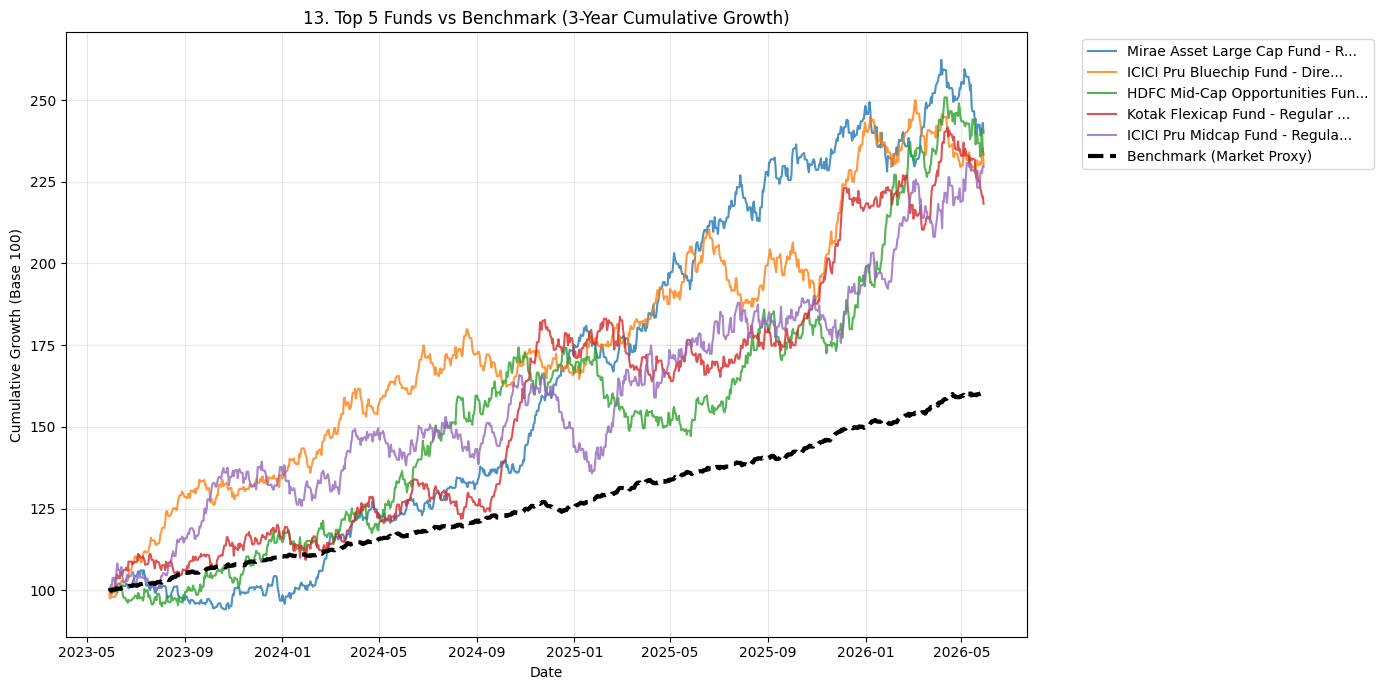

 Successfully saved 'benchmark_comparison.png' to reports folder!

 Tracking Error for Top 5 Funds:


,Scheme Name,Tracking Error (%)
0,Mirae Asset Large Cap Fund - Regular - Growth,11.77
1,ICICI Pru Bluechip Fund - Direct - Growth,12.17
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,15.34
3,Kotak Flexicap Fund - Regular - Growth,13.10
4,ICICI Pru Midcap Fund - Regular - Growth,15.82


In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



# 1. Get Top 5 Funds from our Scorecard
top_5_funds = final_scorecard['Scheme Name'].head(5).tolist()



# 2. Filter 3-Year Data
end_date = daily_returns.index.max()
start_date_3y = end_date - pd.DateOffset(years=3)

# Use the market_returns (average of 40 funds) we created earlier as our Benchmark Proxy
df_compare = daily_returns[top_5_funds].copy()
df_compare['Benchmark (Market Proxy)'] = market_returns

# Filter for last 3 years
df_3y = df_compare[df_compare.index >= start_date_3y].dropna()

# Calculate Cumulative Returns (Base 100) -> Starts everyone at 100 for easy comparison
cumulative_returns = (1 + df_3y).cumprod() * 100



# 3. Plotting the Benchmark Comparison Chart
plt.figure(figsize=(14, 7))

# Plot top 5 funds
for fund in top_5_funds:
    # Shorten the name slightly for the legend
    short_name = fund[:30] + '...' if len(fund) > 30 else fund
    plt.plot(cumulative_returns.index, cumulative_returns[fund], label=short_name, alpha=0.8)

# Plot Benchmark prominently
plt.plot(cumulative_returns.index, cumulative_returns['Benchmark (Market Proxy)'], 
         label='Benchmark (Market Proxy)', color='black', linewidth=3, linestyle='--')

plt.title('13. Top 5 Funds vs Benchmark (3-Year Cumulative Growth)')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth (Base 100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the chart as PNG in the reports folder
plt.savefig('../reports/benchmark_comparison.png')
plt.show()
print(" Successfully saved 'benchmark_comparison.png' to reports folder!")



# 4. Compute Tracking Error
# Formula: std(fund_return - benchmark_return) * sqrt(252)
tracking_errors = []

for fund in top_5_funds:
    # standard deviation of the difference in daily returns
    diff_std = (df_3y[fund] - df_3y['Benchmark (Market Proxy)']).std()
    te_annualized = diff_std * np.sqrt(252)
    
    tracking_errors.append({
        'Scheme Name': fund,
        'Tracking Error (%)': round(te_annualized * 100, 2)
    })

df_te = pd.DataFrame(tracking_errors)
print("\n Tracking Error for Top 5 Funds:")
display(df_te)